# GARCH

El modelo GARCH(1,1) (Generalized Autoregressive Conditional Heteroskedasticity) es el rey indiscutible de las finanzas tradicionales para esta tarea. Su esencia radica en que asume que la varianza actual depende de:
1. Una constante base ($\omega$).
2. Los "shocks" o noticias del día anterior ($\alpha \epsilon^2_{t-1}$).
3. La varianza que ya traíamos del día anterior ($\beta \sigma^2_{t-1}$).
Matemáticamente, la ecuación de la varianza condicional es:
$$\sigma^2_t = \omega + \alpha \epsilon^2_{t-1} + \beta \sigma^2_{t-1}$$

El modelo se basa en:
- Heterocedasticidad: Significa que la varianza (o volatilidad) de los datos no es constante a lo largo del tiempo. 
- Condicional: La volatilidad de hoy depende (está condicionada) de la información de ayer.
- Autorregresiva: El modelo usa sus propios valores pasados para predecir el futuro.
- Generalizada: Es una extensión del modelo ARCH (creado por Robert Engle, premio Nobel), introducida por Tim Bollerslev, que permite que la volatilidad dependa no solo de los shocks pasados, sino también de la volatilidad pasada.\
El objetivo principal de GARCH es modelar el agrupamiento de volatilidad (volatility clustering): el fenómeno empírico donde grandes variaciones en los precios tienden a ser seguidas por grandes variaciones (al alza o a la baja), y pequeñas variaciones por pequeñas variaciones.


# 1. Carga de Datos y Preparación

Partiremos del archivo CSV que generamos en el primer notebook. Una regla de oro al usar la librería arch es escalar los retornos (multiplicarlos por 100 para pasarlos a porcentaje). Si no lo hacemos, los valores son tan pequeños que el optimizador matemático del modelo suele fallar al intentar converger.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from scipy import stats
import warnings
warnings.filterwarnings('ignore') # Para mantener el output limpio

# Configuración visual
plt.style.use('seaborn-v0_8-darkgrid')

# Carga de datos procesados del notebook 1
df = pd.read_csv('..\data\processed\spy_processed.csv', index_col='Date', parse_dates=True)


Como los retornos diarios de un índice como el S&P500 son, por lo general, números muy pequeños, y los modelos GARCH trabajan estimando la varianza (retornos al cuadrado), debemos escalar los datos. Para ello, multiplicamos por 100 los retornos:

In [3]:
# ESCALADO: Multiplicamos por 100 para ayudar al optimizador de la librería 'arch'
# Esto convierte los retornos a porcentajes 
df['Returns_Pct'] = df['Log_Returns'] * 100

# Separamos en Train y Test (dejamos los últimos 2 años para probar el modelo)
split_date = '2024-01-01'
train_data = df[:split_date]
test_data = df[split_date:]

print(f"Tamaño de Entrenamiento: {len(train_data)} días")
print(f"Tamaño de Prueba: {len(test_data)} días")

Tamaño de Entrenamiento: 6016 días
Tamaño de Prueba: 572 días


# 2. Definición, Ajuste e Hipótesis del Modelo GARCH(1,1)

Aquí definimos el modelo. Usaremos una media constante (mean='Constant') y asumiremos que los residuos siguen una distribución normal (dist='Normal'). Aunque en finanzas reales los retornos tienen "colas pesadas", la normal es el mejor punto de partida.

In [4]:
# Definición del Modelo
# p=1 (un rezago del error al cuadrado. El modelo "mira" un día hacia atrás en los errores al cuadrado), q=1 (un rezago de la varianza. El modelo "mira" un día hacia atrás en la propia varianza estimada)
garch = arch_model(df['Returns_Pct'], vol='Garch', p=1, q=1, mean='Constant', dist='Normal')

# Ajustamos el modelo SOLAMENTE usando los datos de entrenamiento para evitar Data Leakage
# La función fit optimiza los parámetros omega, alpha y beta
resultado_garch = garch.fit(last_obs=split_date, disp='off')

# Mostramos el resumen estadístico
print("\n--- Resumen del Modelo GARCH(1,1) ---")
print(resultado_garch.summary())


--- Resumen del Modelo GARCH(1,1) ---
                     Constant Mean - GARCH Model Results                      
Dep. Variable:            Returns_Pct   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -8326.99
Distribution:                  Normal   AIC:                           16662.0
Method:            Maximum Likelihood   BIC:                           16688.8
                                        No. Observations:                 6016
Date:                Wed, Apr 15 2026   Df Residuals:                     6015
Time:                        18:04:19   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.06

Colcusiones:
- `mu` (Coeficiente = 0.0608): Es el retorno diario promedio del activo. Por tanto, el retorno diario real esperado es del $0.0608\%$.
- Significancia de mu (P>|t| = 7.003e-09): Tenemos que $p-valor<<0.05$ por lo que la ganancia promedio diaria del SPY es estadísticamente diferente de cero. En otras palabras, **la bolsa, a largo plazo, tiene una tendencia alcista confirmada**.
- Parámetros ($\omega$, $\alpha$, $\beta$): los tres son estadísticamente significativos:
    - $\omega$ (0.0237): Es la volatilidad base mínima que siempre existe en el mercado, independientemente de lo que pase.
    - $\alpha[1]$ (0.1231): Muestra cómo reacciona el mercado a las noticias de ayer. Un valor del 12.3% significa que el mercado es reactivo a los shocks (como un mal reporte de inflación), pero la volatilidad de hoy no está dominada únicamente por lo que pasó ayer.
    - $\beta[1]$ (0.8602): Muestra la inercia de la volatilidad. Un valor enorme del $86\%$ indica que la volatilidad tiene una memoria muy larga. Si hoy hay pánico, la mayor parte de ese pánico se trasladará a mañana.

A partir de los coeficientes del Volatility Model, podemos calcular las métricas que usaremos para valorar opciones financieras (por ejemplo, en la fórmula de Black-Scholes):
- Persistencia de la Volatilidad: $$\alpha + \beta = 0.1231 + 0.8602 = 0.9833$$
Obtenemos una persistencia de 0.9833 (muy cercana a 1). Significa que los shocks de volatilidad tardan semanas o meses en decaer por completo. El modelo es estable (porque es menor a 1), pero el mercado tiene mucha memoria.
- Varianza Incondicional (Largo Plazo): Podemos calcular hacia qué nivel de varianza tiende a regresar el mercado después de una crisis (reversión a la media): $$V_L = \frac{0.0237}{1 - 0.9833} = \frac{0.0237}{0.0167} \approx 1.419$$
La varianza a largo plazo de tus retornos porcentuales es $1.419$.
- Volatilidad Anualizada (El dato para Options Pricing): Dado que la varianza es $1.419$, la desviación estándar diaria (la volatilidad) es la raíz cuadrada de ese número, es decir, $1.19\%$ al día. Para usar esto en el pricing de opciones, lo anualizamos multiplicándolo por la raíz cuadrada de los días de trading ($\sqrt{252}$): $$1.19\% \times \sqrt{252} \approx 18.9\%$$

Por tanto, el modelo GARCH(1,1) indica que la volatilidad base del SPY a largo plazo es de aproximadamente un $18.9\%$ anual, con altísima persistencia. Ahora, *el reto de las redes neuronales (LSTM y Transformers) será demostrar si, usando indicadores técnicos como el RSI o el MACD, pueden predecir los picos y valles alrededor de ese $18.9\%$ mejor de lo que lo hace este modelo matemático.*

## 2.1. Hipótesis del modelo

- **Estacionariedad de la serie**: La media y la varianza de la serie (en el largo plazo) no deben depender del tiempo. Esta premisa no se satisface: los precios no son estacionarios (tienen tendencia), pero los rendimientos logarítmicos suelen serlo, por eso usamos (`Log_Returns` * 100).
- **Existencia de Efectos ARCH (Heterocedasticidad Condicional)**. No tiene sentido aplicar un modelo GARCH si la volatilidad es constante.
Debe haber evidencia de que los residuos al cuadrado están autocorrelacionados. Es decir, que existen "rachas" de alta y baja volatilidad (volatility clustering). Lo verificamos mediante el **Test de Engle (ARCH-LM)** sobre los residuos de la ecuación de la media. Si el test indica que no hay efectos ARCH, un modelo simple de varianza constante sería suficiente.
- **Independencia de los Residuos (Ausencia de Autocorrelación)**. La ecuación de la media que definimos (mean='Constant') debe ser capaz de extraer toda la estructura lineal de los datos.  Los residuos $\epsilon_t$ no deben tener un patrón predecible en el tiempo. Si hay autocorrelación, significa que el modelo de la media es demasiado simple. Lo verificamos con el **Test de Ljung-Box** sobre los residuos.
- **Condiciones de Positividad y Estabilidad**. Para que el modelo sea físicamente posible (la volatilidad no puede ser negativa ni infinita), los parámetros estimados deben cumplir:
    - Positividad: $\omega > 0, \alpha \geq 0$ y $\beta \geq 0$. Si $\alpha$ o $\beta$ fueran negativos, podríamos obtener una varianza negativa, lo cual es matemáticamente imposible.
    - Estabilidad (Reversión a la media): En un GARCH(1,1), se debe cumplir que: $$\alpha + \beta < 1$$
        - Si $\alpha + \beta = 1$, tenemos un modelo IGARCH (persistencia infinita).
        - Si $\alpha + \beta > 1$, la volatilidad es explosiva y el modelo no es válido para pronósticos a largo plazo.
- **Hipótesis sobre la Distribución de los Errores**. Aunque GARCH se puede estimar con diferentes distribuciones, el modelo estándar asume una base:
    - Normalidad: Los errores estandarizados $z_t$ deben seguir una distribución normal $\mathcal{N}(0,1)$. Aunque, como hemos comentado antes, si los residuos fallan el test de Jarque-Bera, esta hipótesis se rompe. En ese caso, la hipótesis cambia a una Distribución t-Student o GED (Generalized Error Distribution) para capturar las colas pesadas.

In [5]:
returns = train_data['Returns_Pct'].dropna()
residuos_std = (resultado_garch.resid / resultado_garch.conditional_volatility).dropna()

print("=== 1. TEST DE ESTACIONARIEDAD (ADF) ===")
adf_test = adfuller(returns)
print(f"Estadístico ADF: {adf_test[0]:.4f}")
print(f"p-valor: {adf_test[1]:.4e}")
print("Resultado:", "Estacionaria" if adf_test[1] < 0.05 else "No Estacionaria")
print("-" * 30)

print("=== 2. TEST DE EFECTOS ARCH (Engle's LM Test) ===")
# Se aplica sobre los residuos de la media (no los estandarizados)
lm_test = het_arch(resultado_garch.resid.dropna())
print(f"p-valor del test ARCH: {lm_test[1]:.4e}")
print("Resultado:", "Existen efectos ARCH (GARCH es necesario)" if lm_test[1] < 0.05 else "No hay efectos ARCH")
print("-" * 30)

print("=== 3. AUSENCIA DE AUTOCORRELACIÓN (Ljung-Box) ===")
# Verificamos si los residuos estandarizados son ruido blanco
lb_test = acorr_ljungbox(residuos_std, lags=[10], return_df=True)
p_val_lb = lb_test['lb_pvalue'].values[0]
print(f"p-valor Ljung-Box (lag 10): {p_val_lb:.4f}")
print("Resultado:", "Sin autocorrelación (Modelo de media OK)" if p_val_lb > 0.05 else "Hay autocorrelación (Revisar media)")
print("-" * 30)

print("=== 4. ESTABILIDAD Y POSITIVIDAD DE PARÁMETROS ===")
omega = resultado_garch.params['omega']
alpha = resultado_garch.params['alpha[1]']
beta = resultado_garch.params['beta[1]']
suma_persistencial = alpha + beta

print(f"Omega: {omega:.4f} (> 0: {omega > 0})")
print(f"Alpha: {alpha:.4f} (>= 0: {alpha >= 0})")
print(f"Beta: {beta:.4f} (>= 0: {beta >= 0})")
print(f"Persistencia (Alpha + Beta): {suma_persistencial:.4f}")
print("Resultado:", "Modelo Estable" if suma_persistencial < 1 else "Modelo Inestable/Explosivo")
print("-" * 30)

print("=== 5. TEST DE NORMALIDAD (Jarque-Bera) ===")
jb_test = stats.jarque_bera(residuos_std)
print(f"p-valor Jarque-Bera: {jb_test[1]:.4e}")
print("Resultado:", "Residuos Normales" if jb_test[1] > 0.05 else "Residuos NO Normales (Colas pesadas)")

=== 1. TEST DE ESTACIONARIEDAD (ADF) ===
Estadístico ADF: -19.3330
p-valor: 0.0000e+00
Resultado: Estacionaria
------------------------------
=== 2. TEST DE EFECTOS ARCH (Engle's LM Test) ===
p-valor del test ARCH: 0.0000e+00
Resultado: Existen efectos ARCH (GARCH es necesario)
------------------------------
=== 3. AUSENCIA DE AUTOCORRELACIÓN (Ljung-Box) ===
p-valor Ljung-Box (lag 10): 0.0626
Resultado: Sin autocorrelación (Modelo de media OK)
------------------------------
=== 4. ESTABILIDAD Y POSITIVIDAD DE PARÁMETROS ===
Omega: 0.0237 (> 0: True)
Alpha: 0.1231 (>= 0: True)
Beta: 0.8602 (>= 0: True)
Persistencia (Alpha + Beta): 0.9833
Resultado: Modelo Estable
------------------------------
=== 5. TEST DE NORMALIDAD (Jarque-Bera) ===
p-valor Jarque-Bera: 6.8116e-230
Resultado: Residuos NO Normales (Colas pesadas)


Como vemos, se satisfacen todas las hipótesis excepto la normalidad de los residuos, por lo que podemos considerar el siguiente ajuste:

In [6]:

garch2 = arch_model(df['Returns_Pct'], vol='Garch', p=1, q=1, mean='Constant', dist='t')

resultado_garch2 = garch2.fit(last_obs=split_date, disp='off')


print("\n--- Resumen del Modelo GARCH(1,1) ---")
print(resultado_garch2.summary())


--- Resumen del Modelo GARCH(1,1) ---
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                  Returns_Pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -8197.60
Distribution:      Standardized Student's t   AIC:                           16405.2
Method:                  Maximum Likelihood   BIC:                           16438.7
                                              No. Observations:                 6016
Date:                      Wed, Apr 15 2026   Df Residuals:                     6015
Time:                              18:04:19   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
------------------------------------------

In [7]:
returns = train_data['Returns_Pct'].dropna()
residuos_std = (resultado_garch2.resid / resultado_garch2.conditional_volatility).dropna()

print("=== 1. TEST DE ESTACIONARIEDAD (ADF) ===")
adf_test = adfuller(returns)
print(f"Estadístico ADF: {adf_test[0]:.4f}")
print(f"p-valor: {adf_test[1]:.4e}")
print("Resultado:", "Estacionaria" if adf_test[1] < 0.05 else "No Estacionaria")
print("-" * 30)

print("=== 2. TEST DE EFECTOS ARCH (Engle's LM Test) ===")
# Se aplica sobre los residuos de la media (no los estandarizados)
lm_test = het_arch(resultado_garch2.resid.dropna())
print(f"p-valor del test ARCH: {lm_test[1]:.4e}")
print("Resultado:", "Existen efectos ARCH (GARCH es necesario)" if lm_test[1] < 0.05 else "No hay efectos ARCH")
print("-" * 30)

print("=== 3. AUSENCIA DE AUTOCORRELACIÓN (Ljung-Box) ===")
# Verificamos si los residuos estandarizados son ruido blanco
lb_test = acorr_ljungbox(residuos_std, lags=[10], return_df=True)
p_val_lb = lb_test['lb_pvalue'].values[0]
print(f"p-valor Ljung-Box (lag 10): {p_val_lb:.4f}")
print("Resultado:", "Sin autocorrelación (Modelo de media OK)" if p_val_lb > 0.05 else "Hay autocorrelación (Revisar media)")
print("-" * 30)

print("=== 4. ESTABILIDAD Y POSITIVIDAD DE PARÁMETROS ===")
omega = resultado_garch2.params['omega']
alpha = resultado_garch2.params['alpha[1]']
beta = resultado_garch2.params['beta[1]']
suma_persistencial = alpha + beta

print(f"Omega: {omega:.4f} (> 0: {omega > 0})")
print(f"Alpha: {alpha:.4f} (>= 0: {alpha >= 0})")
print(f"Beta: {beta:.4f} (>= 0: {beta >= 0})")
print(f"Persistencia (Alpha + Beta): {suma_persistencial:.4f}")
print("Resultado:", "Modelo Estable" if suma_persistencial < 1 else "Modelo Inestable/Explosivo")
print("-" * 30)

print("=== 5. TEST DE NORMALIDAD (Jarque-Bera) ===")
jb_test = stats.jarque_bera(residuos_std)
print(f"p-valor Jarque-Bera: {jb_test[1]:.4e}")
print("Resultado:", "Residuos Normales" if jb_test[1] > 0.05 else "Residuos NO Normales (Colas pesadas)")

=== 1. TEST DE ESTACIONARIEDAD (ADF) ===
Estadístico ADF: -19.3330
p-valor: 0.0000e+00
Resultado: Estacionaria
------------------------------
=== 2. TEST DE EFECTOS ARCH (Engle's LM Test) ===
p-valor del test ARCH: 0.0000e+00
Resultado: Existen efectos ARCH (GARCH es necesario)
------------------------------
=== 3. AUSENCIA DE AUTOCORRELACIÓN (Ljung-Box) ===
p-valor Ljung-Box (lag 10): 0.0564
Resultado: Sin autocorrelación (Modelo de media OK)
------------------------------
=== 4. ESTABILIDAD Y POSITIVIDAD DE PARÁMETROS ===
Omega: 0.0146 (> 0: True)
Alpha: 0.1275 (>= 0: True)
Beta: 0.8696 (>= 0: True)
Persistencia (Alpha + Beta): 0.9971
Resultado: Modelo Estable
------------------------------
=== 5. TEST DE NORMALIDAD (Jarque-Bera) ===
p-valor Jarque-Bera: 0.0000e+00
Resultado: Residuos NO Normales (Colas pesadas)


# 3. Predicción (Rolling Forecast)

Ahora vamos a poner a prueba el modelo con los datos que no ha visto. No queremos predecir todo el conjunto de prueba de golpe, ya que la volatilidad cambia rápido. Haremos un Rolling Forecast de 1 paso adelante: el modelo usa la información hasta el día $T$ para predecir la volatilidad del día $T+1$, y así sucesivamente a lo largo de todo nuestro set de test:

In [8]:
# Generación de Predicciones Out-of-Sample (Test)

# Al pasar 'start=split_date', la librería automáticamente hace un rolling forecast: En lugar de 
# hacer una única predicción, el modelo se sitúa en cada día del set de test, mira la información 
# disponible hasta ese momento y predice el día siguiente. Así sucesivamente para todos los días desde el 1 de enero de 2024.
# previendo 1 paso adelante para cada día del test set (horizon=1)
forecasts = resultado_garch.forecast(horizon=1, start=split_date, align='target')

# Extraemos la varianza predicha (viene en porcentaje al cuadrado por el escalado inicial)
predicted_variance_pct = forecasts.variance['h.1'].dropna()

# DESESCALADO: Convertimos la varianza a volatilidad (desviación estándar),
# la dividimos por 100 para volver a la escala original de log-retornos,
# y la multiplicamos por sqrt(252) para anualizarla y compararla con nuestro Target.
predicted_vol_daily = np.sqrt(predicted_variance_pct) / 100
df_predictions = pd.DataFrame(index=predicted_variance_pct.index)
df_predictions['GARCH_Pred_Vol'] = predicted_vol_daily * np.sqrt(252)

# Unimos con la Volatilidad Realizada real para comparar
df_predictions = df_predictions.join(df['Realized_Vol'])

# 4. Evaluación Visual y Exportación

Finalmente, graficamos los resultados para ver cuán bueno es nuestro modelo GARCH y cuánto pudo anticipar los movimientos de la Volatilidad Realizada durante el periodo de prueba:

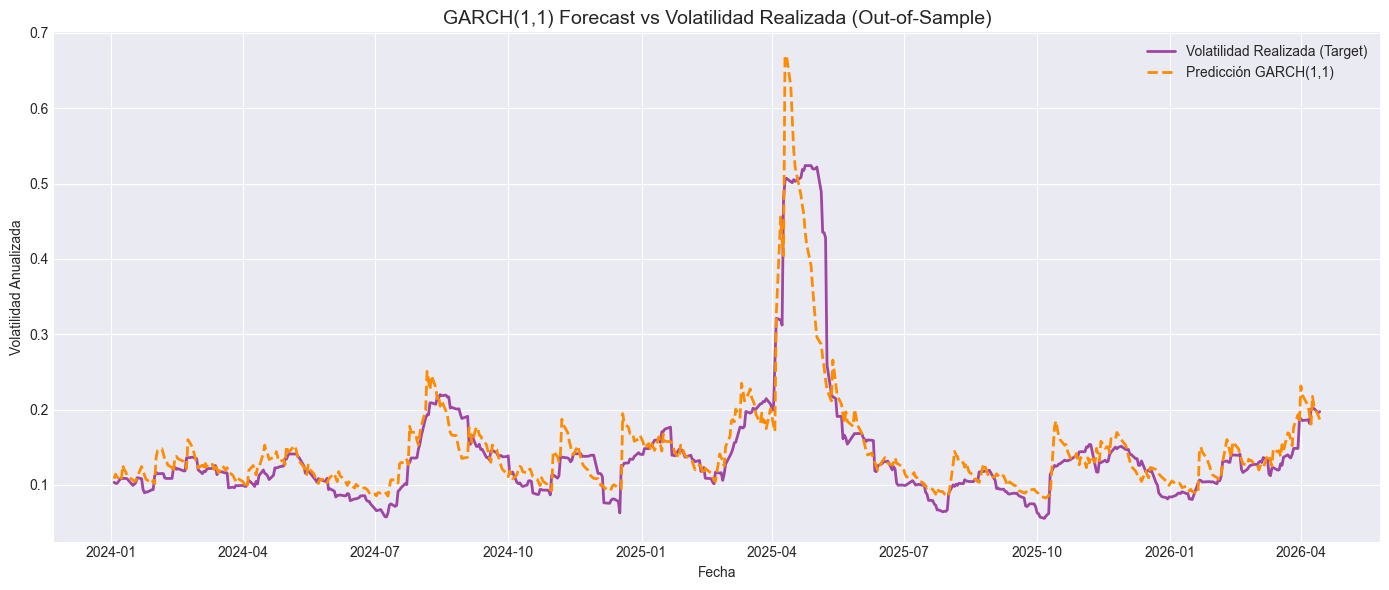

In [9]:
# Visualización de Resultados
plt.figure(figsize=(14, 6))

# Graficamos la Realidad vs la Predicción
plt.plot(df_predictions.index, df_predictions['Realized_Vol'], 
         label='Volatilidad Realizada (Target)', color='purple', alpha=0.7, linewidth=2)
         
plt.plot(df_predictions.index, df_predictions['GARCH_Pred_Vol'], 
         label='Predicción GARCH(1,1)', color='darkorange', linestyle='--', linewidth=2)

plt.title('GARCH(1,1) Forecast vs Volatilidad Realizada (Out-of-Sample)', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Volatilidad Anualizada')
plt.legend()
plt.tight_layout()
plt.show()

# Guardamos las predicciones para el Notebook 4 (Comparación final)
df_predictions.to_csv('..\data\processed\garch_predictions.csv')


En el notebook 4 se calcularán las métricas de error para comparar los modelos.